Sampling Rate: 22050
Signal Length: 99229


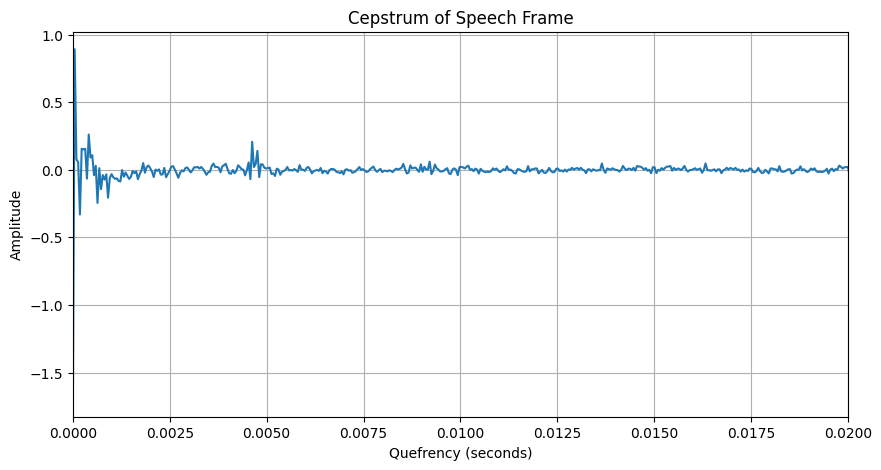


--- Pitch Estimation ---
Pitch Period: 0.009206349206349206 seconds
Fundamental Frequency (F0): 108.62068965517241 Hz


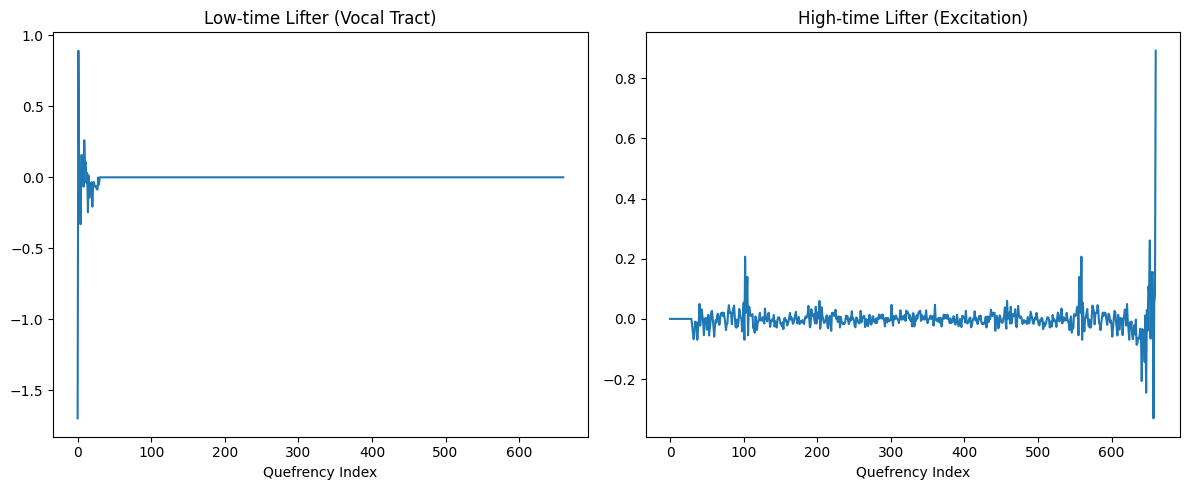

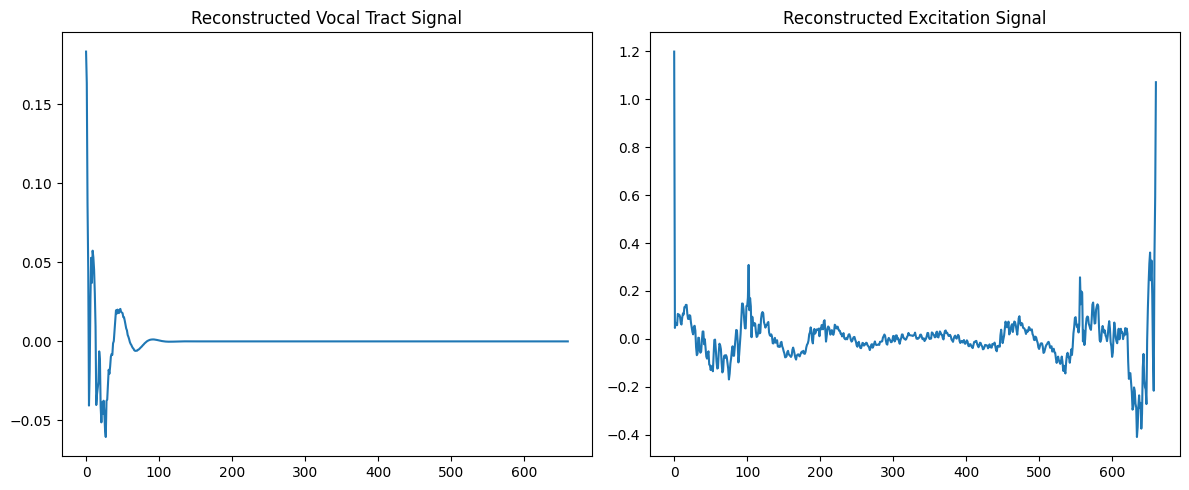


--- Summary ---
Cepstrum computed successfully.
Pitch extracted using cepstral peak.
Liftering separated vocal tract and excitation components.


In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

file_path = "/content/LJ050-0274.wav"
signal, sr = librosa.load(file_path, sr=None)

print("Sampling Rate:", sr)
print("Signal Length:", len(signal))

frame_duration = 0.03
frame_size = int(frame_duration * sr)

start_sample = 1000
frame = signal[start_sample:start_sample + frame_size]

frame = frame * np.hamming(len(frame))

spectrum = np.fft.fft(frame)
log_spectrum = np.log(np.abs(spectrum) + 1e-10)
cepstrum = np.fft.ifft(log_spectrum).real

quefrency = np.arange(len(cepstrum)) / sr

plt.figure(figsize=(10, 5))
plt.plot(quefrency, cepstrum)
plt.title("Cepstrum of Speech Frame")
plt.xlabel("Quefrency (seconds)")
plt.ylabel("Amplitude")
plt.xlim(0, 0.02)
plt.grid()
plt.show()

min_q = int(0.005 * sr)
max_q = int(0.02 * sr)

cep_region = cepstrum[min_q:max_q]
peak_index = np.argmax(cep_region) + min_q

pitch_period = peak_index / sr
F0 = 1 / pitch_period

print("\n--- Pitch Estimation ---")
print("Pitch Period:", pitch_period, "seconds")
print("Fundamental Frequency (F0):", F0, "Hz")

lifter_threshold = 30

low_lifter = np.copy(cepstrum)
low_lifter[lifter_threshold:] = 0

high_lifter = np.copy(cepstrum)
high_lifter[:lifter_threshold] = 0

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(low_lifter)
plt.title("Low-time Lifter (Vocal Tract)")
plt.xlabel("Quefrency Index")

plt.subplot(1, 2, 2)
plt.plot(high_lifter)
plt.title("High-time Lifter (Excitation)")
plt.xlabel("Quefrency Index")

plt.tight_layout()
plt.show()

vt_spectrum = np.exp(np.fft.fft(low_lifter))
excitation_spectrum = np.exp(np.fft.fft(high_lifter))

vt_signal = np.fft.ifft(vt_spectrum).real
excitation_signal = np.fft.ifft(excitation_spectrum).real

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(vt_signal)
plt.title("Reconstructed Vocal Tract Signal")

plt.subplot(1,2,2)
plt.plot(excitation_signal)
plt.title("Reconstructed Excitation Signal")

plt.tight_layout()
plt.show()

print("\n--- Summary ---")
print("Cepstrum computed successfully.")
print("Pitch extracted using cepstral peak.")
print("Liftering separated vocal tract and excitation components.")